In [2]:
# Utilizando nest_asyncio para evitar conflito de Event Loop

import nest_asyncio
nest_asyncio.apply()

In [3]:
# Montagem do Drive e Configuração da API KEY

import os
from google.colab import drive, userdata

# Drive:
drive.mount('/content/drive')

# API Key
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Instalação das Dependências

%pip install pydantic-ai google-generativeai python-dotenv --quiet

In [5]:
# Clone do repositório do Github
import os, sys, shutil

REPO_URL = 'https://github.com/JRicLP/GenAI_Ecommerce-Agent'
REPO_DIR = '/content/GenAI_Ecommerce-Agent'

os.chdir('/content')
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone {REPO_URL}

os.chdir(REPO_DIR)
print(f'\nPasta atual: {os.getcwd()}')
print('Conteúdo:', os.listdir('.'))

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print('sys.path configurado')

Cloning into 'GenAI_Ecommerce-Agent'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 75 (delta 41), reused 55 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 23.20 KiB | 1.78 MiB/s, done.
Resolving deltas: 100% (41/41), done.

Pasta atual: /content/GenAI_Ecommerce-Agent
Conteúdo: ['notebook.ipynb', '.git', 'README.md', 'requirements.txt', '.gitignore', 'src']
sys.path configurado


In [7]:
# Cópia do Database do drive para o Notebook:
BANCO_ORIGEM  = '/content/drive/MyDrive/GenAI Database/banco.db'
BANCO_DESTINO = '/content/GenAI_Ecommerce-Agent/banco.db'

if not os.path.exists(BANCO_ORIGEM):
    raise FileNotFoundError(
        f"banco.db não encontrado em '{BANCO_ORIGEM}'.\n"
        'Verifique o caminho no seu Google Drive.'
    )

shutil.copy(BANCO_ORIGEM, BANCO_DESTINO)
print(f"banco.db copiado para o projeto")
print(f'Origem: {BANCO_ORIGEM}')
print(f'Destino: {BANCO_DESTINO}')

banco.db copiado para o projeto
Origem: /content/drive/MyDrive/GenAI Database/banco.db
Destino: /content/GenAI_Ecommerce-Agent/banco.db


In [8]:
# Exploração do Database - 1. Listagem de tabelas e contagem de linhas :

import sqlite3

conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

tabelas = cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

print('Tabelas encontradas no banco:')
for (nome,) in tabelas:
    count = cursor.execute(f'SELECT COUNT(*) FROM {nome}').fetchone()[0]
    print(f'OK - {nome}: {count:,} linhas')


Tabelas encontradas no banco:
OK - dim_consumidores: 99,441 linhas
OK - dim_produtos: 32,951 linhas
OK - dim_vendedores: 3,095 linhas
OK - fat_avaliacoes_pedidos: 95,307 linhas
OK - fat_itens_pedidos: 112,650 linhas
OK - fat_pedido_total: 99,441 linhas
OK - fat_pedidos: 99,441 linhas


In [9]:
# Exploração do Database - 2. Inspeção de colunas e amostragem:
for (nome,) in tabelas:
    cols = [c[1] for c in cursor.execute(f'PRAGMA table_info({nome})').fetchall()]
    amostra = cursor.execute(f'SELECT * FROM {nome} LIMIT 2').fetchall()
    print(f"\n{'='*60}")
    print(f'Tabela: {nome}')
    print(f'Colunas: {cols}')
    print(f'Amostra: {amostra[0]}')


Tabela: dim_consumidores
Colunas: ['id_consumidor', 'prefixo_cep', 'nome_consumidor', 'cidade', 'estado']
Amostra: ('00012a2ce6f8dcda20d059ce98491703', 6273, 'Dr. Davi Pinto', 'OSASCO', 'SP')

Tabela: dim_produtos
Colunas: ['id_produto', 'nome_produto', 'categoria_produto', 'peso_produto_gramas', 'comprimento_centimetros', 'altura_centimetros', 'largura_centimetros']
Amostra: ('00066f42aeeb9f3007548bb9d3f33c38', 'Loção Corporal Preto', 'perfumaria', 300.0, 20.0, 16.0, 16.0)

Tabela: dim_vendedores
Colunas: ['id_vendedor', 'nome_vendedor', 'prefixo_cep', 'cidade', 'estado']
Amostra: ('0015a82c2db000af6aaaf3ae2ecb0532', 'Amanda Sá', 9080, 'SANTO ANDRE', 'SP')

Tabela: fat_avaliacoes_pedidos
Colunas: ['id_avaliacao', 'id_pedido', 'avaliacao', 'titulo_comentario', 'comentario', 'data_comentario', 'data_resposta']
Amostra: ('7bc2406110b926393aa56f80a40eba40', '73fc7af87114b39712e6da79b0a377eb', 4, 'Sem título', 'Sem comentário', '2018-01-18 00:00:00', '2018-01-18 21:46:59')

Tabela: fat_it

In [10]:
# Exploração do Database - 3. Mapeamento de valores únicos das colunas:

status = cursor.execute('SELECT DISTINCT status FROM fat_pedidos').fetchall()
print('Status:', [s[0] for s in status])

prazo = cursor.execute('SELECT DISTINCT entrega_no_prazo FROM fat_pedidos').fetchall()
print('entrega_no_prazo:', [p[0] for p in prazo])

cats = cursor.execute('SELECT DISTINCT categoria_produto FROM dim_produtos').fetchall()
print('Categorias:', [c[0] for c in cats])

periodo = cursor.execute('SELECT MIN(data_pedido), MAX(data_pedido) FROM fat_pedido_total').fetchone()
print('Período:', periodo)

avals = cursor.execute('SELECT MIN(avaliacao), MAX(avaliacao), ROUND(AVG(avaliacao),2) FROM fat_avaliacoes_pedidos').fetchone()
print('Avaliações (min/max/média):', avals)


Status: ['entregue', 'faturado', 'enviado', 'em processamento', 'indisponível', 'cancelado', 'criado', 'aprovado']
entrega_no_prazo: ['Sim', 'Não Entregue', 'Não']
Categorias: ['perfumaria', 'automotivo', 'cama_mesa_banho', 'utilidades_domesticas', 'relogios_presentes', 'cool_stuff', 'consoles_games', 'moveis_decoracao', 'beleza_saude', 'fashion_calcados', 'informatica_acessorios', 'brinquedos', 'pet_shop', 'esporte_lazer', 'ferramentas_jardim', 'moveis_sala', 'malas_acessorios', 'casa_construcao', 'moveis_cozinha_area_de_servico_jantar_e_jardim', 'construcao_ferramentas_construcao', 'moveis_quarto', 'fashion_roupa_masculina', 'construcao_ferramentas_seguranca', 'fashion_bolsas_e_acessorios', 'fraldas_higiene', None, 'telefonia', 'artigos_de_natal', 'papelaria', 'telefonia_fixa', 'livros_interesse_geral', 'eletronicos', 'pc_gamer', 'bebes', 'eletrodomesticos', 'alimentos', 'agro_industria_e_comercio', 'livros_importados', 'construcao_ferramentas_iluminacao', 'bebidas', 'construcao_ferr

In [11]:
# Exploração do Database - 4. Verificação dos relacionamentos:

resultado = cursor.execute("""
    SELECT COUNT(*) FROM fat_pedidos fp
    LEFT JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor
    WHERE dc.id_consumidor IS NULL
""").fetchone()
print(f'Pedidos sem consumidor correspondente: {resultado[0]}')

conn.close()
print('\n Exploração finalizada!')

Pedidos sem consumidor correspondente: 0

 Exploração finalizada!


**Import do Agente e Configurações:**

In [12]:
# Import do agente, graficos e função de exibição

import sqlite3
from src.agent import consultar
from src.graficos import gerar_grafico
from src.tools import execute_sql
from src.anonimizacao import anonimizar_resultado

print('Agente importado com sucesso!')

def exibir_resposta(pergunta: str):
    """Executa uma consulta, exibe o resultado e plota gráfico se sugerido."""
    print(f' Pergunta: {pergunta}')
    try:
        resp = consultar(pergunta)
        print(f'\n Resposta:\n{resp.resposta}')
        print(f'\n SQL gerado:\n{resp.sql_gerado}')
        print(f'\n Tem dados: {resp.tem_dados}')

        # Gerar gráfico automaticamente se sugerido e houver SQL
        if resp.sugestao_grafico and resp.sql_gerado:
          print(f'\n Gerando gráfico do tipo: {resp.sugestao_grafico}')
          try:
            resultado = execute_sql(resp.sql_gerado)
            # Anonimizar antes de plotar
            linhas_seguras = anonimizar_resultado(resultado.colunas, resultado.linhas)
            gerar_grafico(
                colunas=resultado.colunas,
                linhas=linhas_seguras,
                tipo=resp.sugestao_grafico,
                titulo=pergunta
            )
          except Exception as e_graf:
            print(f'Não foi possível gerar o gráfico: {e_graf}')

    except Exception as e:
        print(f'\n Erro: {e}')

Agente importado com sucesso!


**Etapa de Validação - Análises**

 Pergunta: Quais são os 10 produtos mais vendidos?

 Resposta:
Os 10 produtos mais vendidos são:

1. Estante de Livros Luxo (527 vendas)
2. Cobertor Cinza (488 vendas)
3. Cortador de Grama Branco (484 vendas)
4. Kit de Ferramentas Ultra (392 vendas)
5. Kit de Ferramentas Master (388 vendas)
6. Kit de Ferramentas (373 vendas)
7. Cabo HDMI Rosa (343 vendas)
8. Colar (323 vendas)
9. Protetor Solar Verde (281 vendas)
10. Webcam Pro (274 vendas)

 SQL gerado:
SELECT dp.id_produto, dp.nome_produto, COUNT(fi.id_produto) AS total_vendas FROM fat_itens_pedidos fi JOIN dim_produtos dp ON fi.id_produto = dp.id_produto GROUP BY dp.id_produto, dp.nome_produto ORDER BY total_vendas DESC LIMIT 10;

 Tem dados: True

 Gerando gráfico do tipo: barra
A segunda coluna não é numérica — gráfico não gerado.
 Pergunta: Qual a receita total por categoria de produto?

 Resposta:
A receita total por categoria de produto é a seguinte:

1. **Cama, Mesa e Banho:** R$ 1.712.553,67
2. **Beleza e Saúde:** R$ 1.657.37

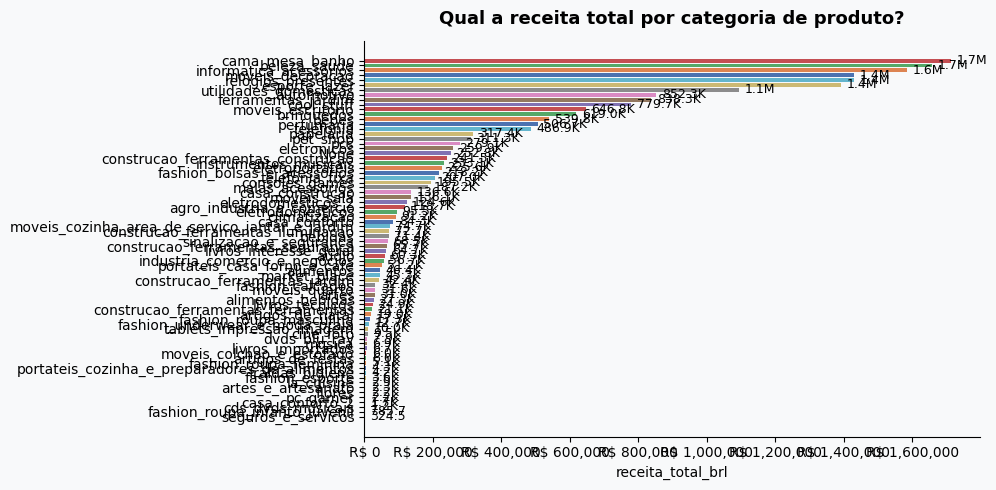

 Pergunta: Qual a quantidade de pedidos por status?

 Resposta:
A quantidade de pedidos por status é a seguinte:

- Entregue: 96.478
- Enviado: 1.107
- Cancelado: 625
- Indisponível: 609
- Faturado: 314
- Em processamento: 301
- Criado: 5
- Aprovado: 2

 SQL gerado:
SELECT status, COUNT(id_pedido) AS quantidade_pedidos FROM fat_pedidos GROUP BY status ORDER BY quantidade_pedidos DESC;

 Tem dados: True

 Gerando gráfico do tipo: barra


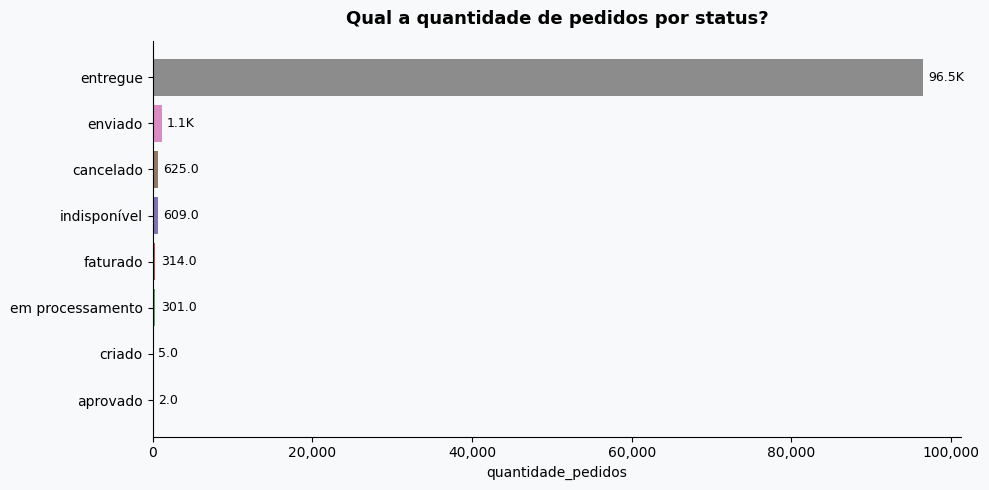

In [13]:
# 1 - Análise de Vendas e Receita:

# Consulta 1:
exibir_resposta('Quais são os 10 produtos mais vendidos?')

# Consulta 2:
exibir_resposta('Qual a receita total por categoria de produto?')

# Consulta 3:
exibir_resposta('Qual a quantidade de pedidos por status?')

In [14]:
# Validação manual - Análise de Vendas e Receitas:

conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

print('Top 10 produtos mais vendidos:')
r = cursor.execute("""
    SELECT dp.nome_produto, COUNT(fi.id_pedido) AS total_vendas
    FROM fat_itens_pedidos fi
    JOIN dim_produtos dp ON fi.id_produto = dp.id_produto
    GROUP BY dp.id_produto
    ORDER BY total_vendas DESC LIMIT 10
""").fetchall()
for i, row in enumerate(r, 1):
    print(f'  {i}. {row[0]}: {row[1]:,} vendas')

print('\n Top 5 - Receita por categoria:')
r = cursor.execute("""
    SELECT dp.categoria_produto,
           ROUND(SUM(fpt.valor_total_pago_brl), 2) AS receita_total_brl
    FROM fat_itens_pedidos fi
    JOIN dim_produtos dp ON fi.id_produto = dp.id_produto
    JOIN fat_pedido_total fpt ON fi.id_pedido = fpt.id_pedido
    GROUP BY dp.categoria_produto
    ORDER BY receita_total_brl DESC LIMIT 5
""").fetchall()
for row in r:
    print(f'  {row[0]}: R$ {row[1]:,.2f}')

print('\n Pedido por Status:')
r = cursor.execute("""
    SELECT status, COUNT(*) AS total
    FROM fat_pedidos GROUP BY status ORDER BY total DESC
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[1]:,}')

conn.close()


Top 10 produtos mais vendidos:
  1. Estante de Livros Luxo: 527 vendas
  2. Cobertor Cinza: 488 vendas
  3. Cortador de Grama Branco: 484 vendas
  4. Kit de Ferramentas Ultra: 392 vendas
  5. Kit de Ferramentas Master: 388 vendas
  6. Kit de Ferramentas: 373 vendas
  7. Cabo HDMI Rosa: 343 vendas
  8. Colar: 323 vendas
  9. Protetor Solar Verde: 281 vendas
  10. Webcam Pro: 274 vendas

 Top 5 - Receita por categoria:
  cama_mesa_banho: R$ 1,712,553.67
  beleza_saude: R$ 1,657,373.12
  informatica_acessorios: R$ 1,585,330.45
  moveis_decoracao: R$ 1,430,176.39
  relogios_presentes: R$ 1,429,216.68

 Pedido por Status:
  entregue: 96,478
  enviado: 1,107
  cancelado: 625
  indisponível: 609
  faturado: 314
  em processamento: 301
  criado: 5
  aprovado: 2


 Pergunta: Qual o percentual de pedidos entregues no prazo por estado?
Erro 503 da API. Tentativa 1/3 — aguardando 15s...

 Resposta:
A análise do percentual de pedidos entregues no prazo por estado revela que o Amapá (AP) lidera com 95.6% de entregas pontuais, seguido por Amazonas (AM) com 95.3% e Acre (AC) com 95.1%. Por outro lado, os estados com menor percentual de entregas no prazo são Alagoas (AL) com 75.5%, Roraima (RR) com 78.3% e Maranhão (MA) com 79.3%. A maioria dos estados apresenta um percentual de entregas no prazo acima de 80%.

 SQL gerado:
SELECT dc.estado, COUNT(*) AS total_pedidos, SUM(CASE WHEN fp.entrega_no_prazo = 'Sim' THEN 1 ELSE 0 END) AS entregues_no_prazo, ROUND(100.0 * SUM(CASE WHEN fp.entrega_no_prazo = 'Sim' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_no_prazo FROM fat_pedidos fp JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor GROUP BY dc.estado ORDER BY pct_no_prazo DESC;

 Tem dados: True

 Gerando gráfico do tipo: barra


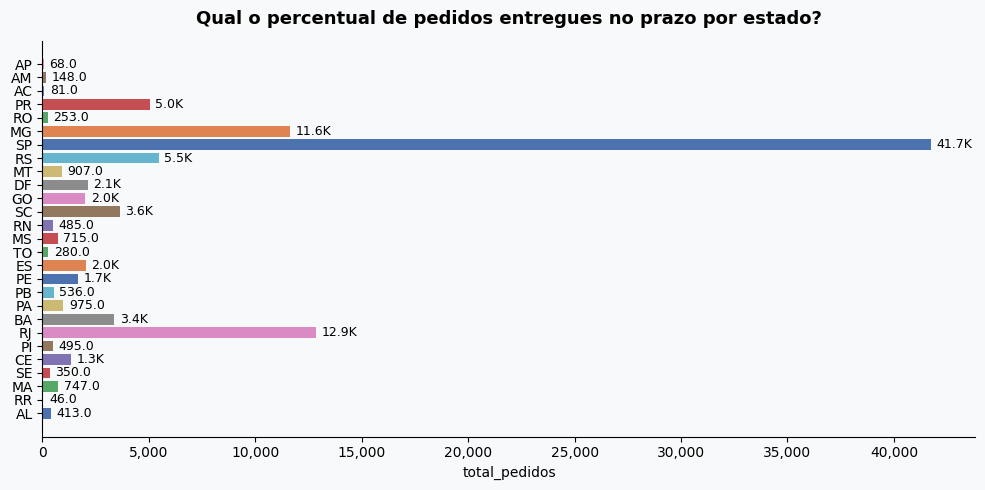

 Pergunta: Quais os estados com maior atraso médio nas entregas?

 Resposta:
A consulta revelou que, em média, as entregas em todos os estados estão sendo realizadas *antes* da data estimada, e não com atraso. Portanto, não há estados com "maior atraso médio" conforme solicitado. Os estados listados abaixo são aqueles com a *menor* antecedência média na entrega, ou seja, estão mais próximos de ter um atraso zero ou um pequeno atraso, embora ainda entreguem antes do prazo médio:

1. **AL**: -8.71 dias de antecedência média
2. **MA**: -9.57 dias de antecedência média
3. **SE**: -10.02 dias de antecedência média
4. **ES**: -10.50 dias de antecedência média
5. **BA**: -10.79 dias de antecedência média

 SQL gerado:
SELECT dc.estado, ROUND(AVG(fp.diferenca_entrega_dias), 2) AS atraso_medio_dias FROM fat_pedidos fp JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor WHERE fp.status = 'entregue' GROUP BY dc.estado ORDER BY atraso_medio_dias DESC;

 Tem dados: True
 Pergunta: Qual 

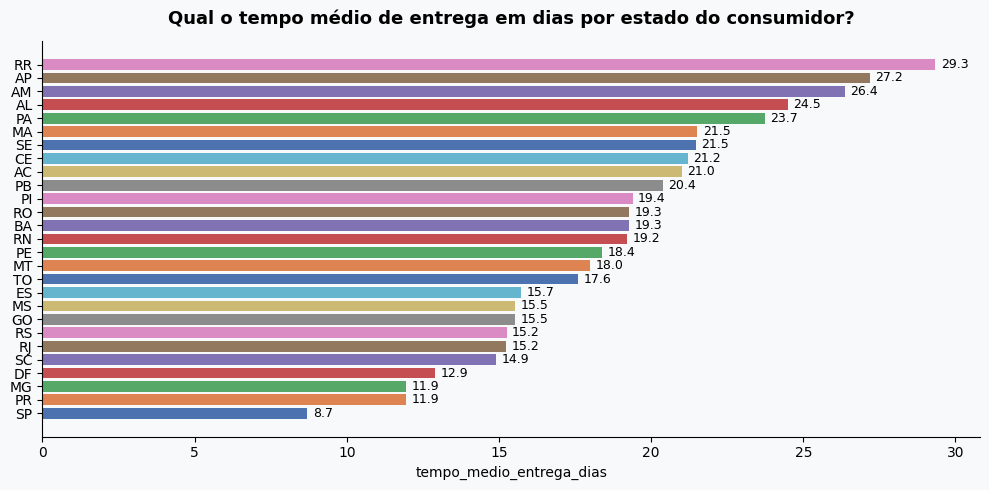

In [15]:
# 2 - Análise de Entrega e Logística:

# Consulta 1:
exibir_resposta('Qual o percentual de pedidos entregues no prazo por estado?')

# Consulta 2:
exibir_resposta('Quais os estados com maior atraso médio nas entregas?')

# Consulta 3:
exibir_resposta('Qual o tempo médio de entrega em dias por estado do consumidor?')


In [16]:
# Validação manual - Análise de Entrega e Logística:

conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

print('Top 10 - Porcentagem de entrega no prazo por estado:')
r = cursor.execute("""
    SELECT dc.estado, COUNT(*) AS total_pedidos,
           SUM(CASE WHEN fp.entrega_no_prazo = 'Sim' THEN 1 ELSE 0 END) AS no_prazo,
           ROUND(100.0 * SUM(CASE WHEN fp.entrega_no_prazo = 'Sim' THEN 1 ELSE 0 END)
                 / COUNT(*), 1) AS pct_no_prazo
    FROM fat_pedidos fp
    JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor
    GROUP BY dc.estado ORDER BY pct_no_prazo DESC LIMIT 10
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[3]}% no prazo ({row[1]:,} pedidos)')

print('\n Estados com maior atraso médio:')
r = cursor.execute("""
    SELECT dc.estado,
           ROUND(AVG(fp.diferenca_entrega_dias), 1) AS atraso_medio_dias
    FROM fat_pedidos fp
    JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor
    WHERE fp.entrega_no_prazo = 'Não'
    GROUP BY dc.estado ORDER BY atraso_medio_dias DESC LIMIT 10
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[1]} dias de atraso médio')

conn.close()

Top 10 - Porcentagem de entrega no prazo por estado:
  AP: 95.6% no prazo (68 pedidos)
  AM: 95.3% no prazo (148 pedidos)
  AC: 95.1% no prazo (81 pedidos)
  PR: 93.6% no prazo (5,045 pedidos)
  RO: 93.3% no prazo (253 pedidos)
  MG: 93.1% no prazo (11,635 pedidos)
  SP: 92.6% no prazo (41,746 pedidos)
  RS: 91.8% no prazo (5,466 pedidos)
  MT: 91.8% no prazo (907 pedidos)
  DF: 91.7% no prazo (2,140 pedidos)

 Estados com maior atraso médio:
  AP: 72.5 dias de atraso médio
  RR: 36.4 dias de atraso médio
  AM: 30.3 dias de atraso médio
  AC: 18.7 dias de atraso médio
  SE: 16.2 dias de atraso médio
  CE: 15.2 dias de atraso médio
  RN: 14.5 dias de atraso médio
  RJ: 13.5 dias de atraso médio
  PI: 13.3 dias de atraso médio
  PA: 12.8 dias de atraso médio


 Pergunta: Qual a média de avaliação geral dos pedidos?

 Resposta:
A média de avaliação geral dos pedidos é de aproximadamente 4.11.

 SQL gerado:
SELECT AVG(avaliacao) AS media_avaliacao_geral FROM fat_avaliacoes_pedidos;

 Tem dados: True
 Pergunta: Quais os 10 vendedores com melhor avaliação média? Considere apenas vendedores com pelo menos 5 avaliações.

 Resposta:
Os 10 vendedores com a melhor avaliação média, considerando apenas aqueles com pelo menos 5 avaliações, são:

1. Stella Nogueira (Média: 5.0, Total de Avaliações: 5)
2. Emanuel Dias (Média: 5.0, Total de Avaliações: 11)
3. Ana Sophia Barbosa (Média: 5.0, Total de Avaliações: 5)
4. Bárbara Sá (Média: 5.0, Total de Avaliações: 5)
5. Calebe Araújo (Média: 5.0, Total de Avaliações: 15)
6. Ísis Siqueira (Média: 5.0, Total de Avaliações: 5)
7. Luna Marques (Média: 5.0, Total de Avaliações: 6)
8. Sra. Ana Carolina da Rocha (Média: 5.0, Total de Avaliações: 5)
9. Henrique Rodrigues (Média: 5.0, Total de Avaliações: 6)
10. Otávi

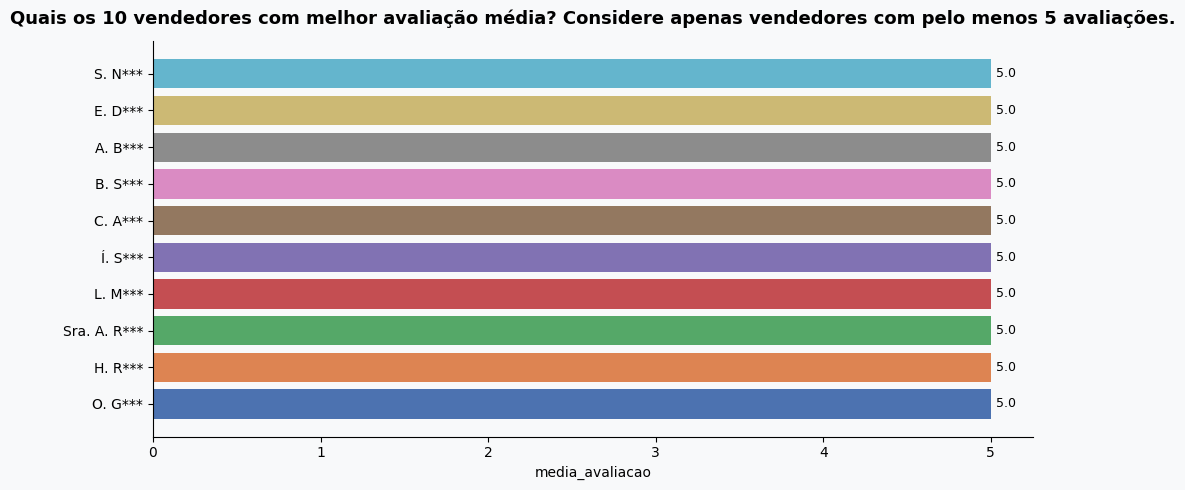

 Pergunta: Quais categorias de produto têm maior taxa de avaliação negativa?

 Resposta:
As categorias de produto com as maiores taxas de avaliação negativa (avaliações <= 2) são:

1. **Seguros e serviços**: 50,0%
2. **Portáteis cozinha e preparadores de alimentos**: 38,46%
3. **PC gamer**: 33,33%
4. **Fashion roupa masculina**: 28,91%
5. **Fraldas higiene**: 25,64%
6. **Móveis escritório**: 24,03%
7. **La cuisine**: 23,08%
8. **Telefonia fixa**: 22,98%
9. Houve um valor numérico sem nome de categoria, com taxa de 21,22%.
10. **Áudio**: 20,18%

Isso significa que 'Seguros e serviços' é a categoria que mais frequentemente recebe avaliações negativas, com metade de suas avaliações sendo 2 ou menos.

 SQL gerado:
SELECT dp.categoria_produto,       CAST(SUM(CASE WHEN fa.avaliacao <= 2 THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(fa.id_avaliacao) AS taxa_avaliacao_negativa_pct FROM fat_avaliacoes_pedidos fa JOIN fat_itens_pedidos fi ON fa.id_pedido = fi.id_pedido JOIN dim_produtos dp ON fi.id_

In [17]:
# 3 - Análise de Satisfação e Avaliações:

# Consulta 1:
exibir_resposta('Qual a média de avaliação geral dos pedidos?')

# Consulta 2:
exibir_resposta('Quais os 10 vendedores com melhor avaliação média? Considere apenas vendedores com pelo menos 5 avaliações.')

# Consulta 3:
exibir_resposta('Quais categorias de produto têm maior taxa de avaliação negativa?')


In [19]:
# Validação manual - Análise de Satisfação e Avaliações:

conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

print('Média geral de avaliação:')
r = cursor.execute("""
    SELECT ROUND(AVG(avaliacao), 2) AS media_geral, COUNT(*) AS total
    FROM fat_avaliacoes_pedidos
""").fetchone()
print(f'  Média: {r[0]} | Total de avaliações: {r[1]:,}')

print('\n Top 10 vendedores por avaliação (Mínimo de 5 avaliações):')
r = cursor.execute("""
    SELECT dv.nome_vendedor,
           ROUND(AVG(fa.avaliacao), 2) AS media_avaliacao,
           COUNT(fa.id_avaliacao) AS total_avaliacoes
    FROM fat_itens_pedidos fi
    JOIN dim_vendedores dv ON fi.id_vendedor = dv.id_vendedor
    JOIN fat_avaliacoes_pedidos fa ON fi.id_pedido = fa.id_pedido
    GROUP BY dv.id_vendedor
    HAVING total_avaliacoes >= 5
    ORDER BY media_avaliacao DESC LIMIT 10
""").fetchall()
for i, row in enumerate(r, 1):
    print(f'  {i}. {row[0]}: {row[1]} ({row[2]} avaliações)')

print('\n Categorias com maior taxa de avaliação negativa (Mín.de 10 avaliações):')
r = cursor.execute("""
    SELECT dp.categoria_produto, COUNT(*) AS total,
           SUM(CASE WHEN fa.avaliacao <= 2 THEN 1 ELSE 0 END) AS negativas,
           ROUND(100.0 * SUM(CASE WHEN fa.avaliacao <= 2 THEN 1 ELSE 0 END)
                 / COUNT(*), 1) AS pct_negativa
    FROM fat_itens_pedidos fi
    JOIN dim_produtos dp ON fi.id_produto = dp.id_produto
    JOIN fat_avaliacoes_pedidos fa ON fi.id_pedido = fa.id_pedido
    WHERE dp.categoria_produto IS NOT NULL
    GROUP BY dp.categoria_produto
    HAVING total >= 10
    ORDER BY pct_negativa DESC LIMIT 10
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[3]}% negativas ({row[2]} de {row[1]})')

conn.close()

Média geral de avaliação:
  Média: 4.11 | Total de avaliações: 95,307

 Top 10 vendedores por avaliação (Mínimo de 5 avaliações):
  1. Dr. Lucas da Rocha: 5.0 (8 avaliações)
  2. Dr. Théo Montenegro: 5.0 (5 avaliações)
  3. Bruna Brito: 5.0 (6 avaliações)
  4. Noah Silveira: 5.0 (7 avaliações)
  5. Srta. Yasmin das Neves: 5.0 (8 avaliações)
  6. Yan Vieira: 5.0 (5 avaliações)
  7. Liam da Mota: 5.0 (7 avaliações)
  8. Sr. Kaique Lima: 5.0 (7 avaliações)
  9. Sra. Ana Júlia Pastor: 5.0 (5 avaliações)
  10. Isabelly Vasconcelos: 5.0 (5 avaliações)

 Categorias com maior taxa de avaliação negativa (Mín.de 10 avaliações):
  portateis_cozinha_e_preparadores_de_alimentos: 38.5% negativas (5 de 13)
  fashion_roupa_masculina: 28.9% negativas (37 de 128)
  fraldas_higiene: 25.6% negativas (10 de 39)
  moveis_escritorio: 24.0% negativas (382 de 1590)
  la_cuisine: 23.1% negativas (3 de 13)
  telefonia_fixa: 23.0% negativas (57 de 248)
  audio: 20.2% negativas (69 de 342)
  casa_conforto_2: 20.0%

 Pergunta: Quais estados têm maior volume de pedidos e qual o ticket médio por estado?

 Resposta:
Os estados com maior volume de pedidos são São Paulo (SP) com 41.746 pedidos, Rio de Janeiro (RJ) com 12.852 pedidos e Minas Gerais (MG) com 11.635 pedidos.

Em relação ao ticket médio por estado:
- São Paulo (SP): R$ 143,69
- Rio de Janeiro (RJ): R$ 166,85
- Minas Gerais (MG): R$ 160,92

Podemos observar que, embora São Paulo tenha o maior volume de pedidos, seu ticket médio é menor em comparação com Rio de Janeiro e Minas Gerais. Outros estados, como Paraíba (PB) com R$ 264,08 e Acre (AC) com R$ 242,97, apresentam tickets médios mais elevados, apesar de terem volumes de pedidos significativamente menores.

 SQL gerado:
SELECT dc.estado, COUNT(fpt.id_pedido) AS volume_pedidos, ROUND(AVG(fpt.valor_total_pago_brl), 2) AS ticket_medio_brl FROM fat_pedido_total fpt JOIN dim_consumidores dc ON fpt.id_consumidor = dc.id_consumidor GROUP BY dc.estado ORDER BY volume_pedidos DESC;

 Tem dados: T

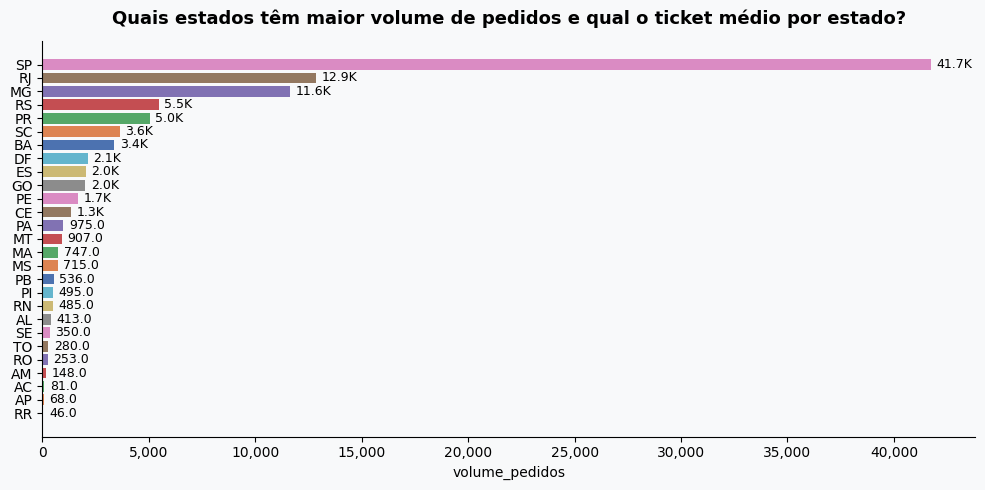

 Pergunta: Quais estados têm maior atraso médio nas entregas para os consumidores?
Erro 503 da API. Tentativa 1/3 — aguardando 15s...

 Resposta:
A análise dos dados revela que, em média, as entregas em todos os estados brasileiros ocorrem antes do prazo estimado. No entanto, os estados com o 'maior atraso médio' (ou, mais precisamente, o menor adiantamento médio em relação à data estimada) são aqueles cujas entregas estão, em média, menos dias à frente do previsto. Os estados que apresentam o menor adiantamento médio nas entregas, e que, portanto, poderiam ser considerados com um 'atraso médio' comparativamente maior são:

1. **Alagoas (AL)**: Média de -8.71 dias (entregas, em média, 8.71 dias antes do previsto)
2. **Maranhão (MA)**: Média de -9.57 dias
3. **Sergipe (SE)**: Média de -10.02 dias
4. **Espírito Santo (ES)**: Média de -10.50 dias
5. **Bahia (BA)**: Média de -10.79 dias

Isso significa que, enquanto a maioria dos estados entrega com grande antecedência, estes estados estão

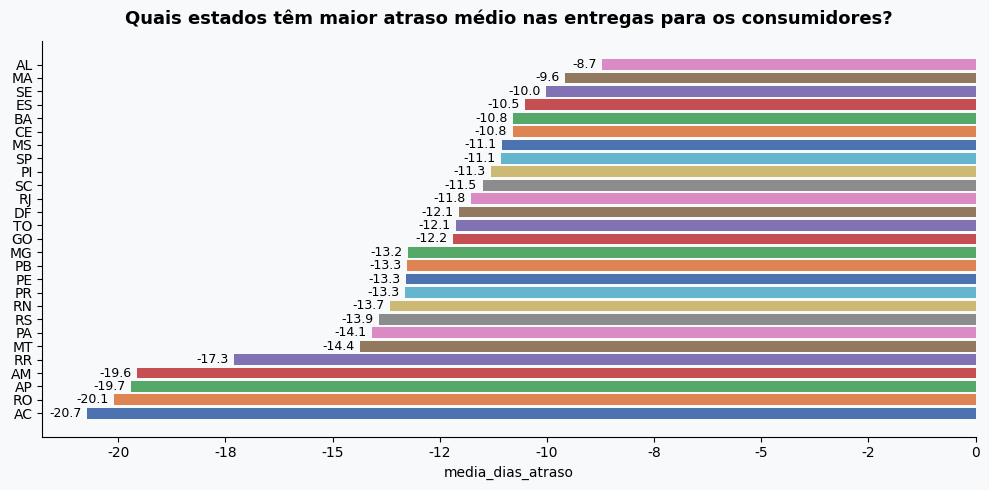

 Pergunta: Qual a distribuição de pedidos entre as regiões brasileiras? Agrupe os estados: Sul (RS, SC, PR), Sudeste (SP, RJ, MG, ES), Centro-Oeste (GO, MT, MS, DF), Nordeste (BA, PE, CE, MA, PB, RN, AL, SE, PI) e Norte (AM, PA, AC, RO, RR, AP, TO).

 Resposta:
A distribuição de pedidos entre as regiões brasileiras é a seguinte:

- Sudeste: 68.266 pedidos
- Sul: 14.148 pedidos
- Nordeste: 9.394 pedidos
- Centro-Oeste: 5.782 pedidos
- Norte: 1.851 pedidos

A região Sudeste concentra a maior parte dos pedidos, seguida pelo Sul e Nordeste. As regiões Centro-Oeste e Norte apresentam um volume menor de pedidos em comparação.

 SQL gerado:
SELECT CASE WHEN dc.estado IN ('RS', 'SC', 'PR') THEN 'Sul' WHEN dc.estado IN ('SP', 'RJ', 'MG', 'ES') THEN 'Sudeste' WHEN dc.estado IN ('GO', 'MT', 'MS', 'DF') THEN 'Centro-Oeste' WHEN dc.estado IN ('BA', 'PE', 'CE', 'MA', 'PB', 'RN', 'AL', 'SE', 'PI') THEN 'Nordeste' WHEN dc.estado IN ('AM', 'PA', 'AC', 'RO', 'RR', 'AP', 'TO') THEN 'Norte' ELSE 'Outros' 

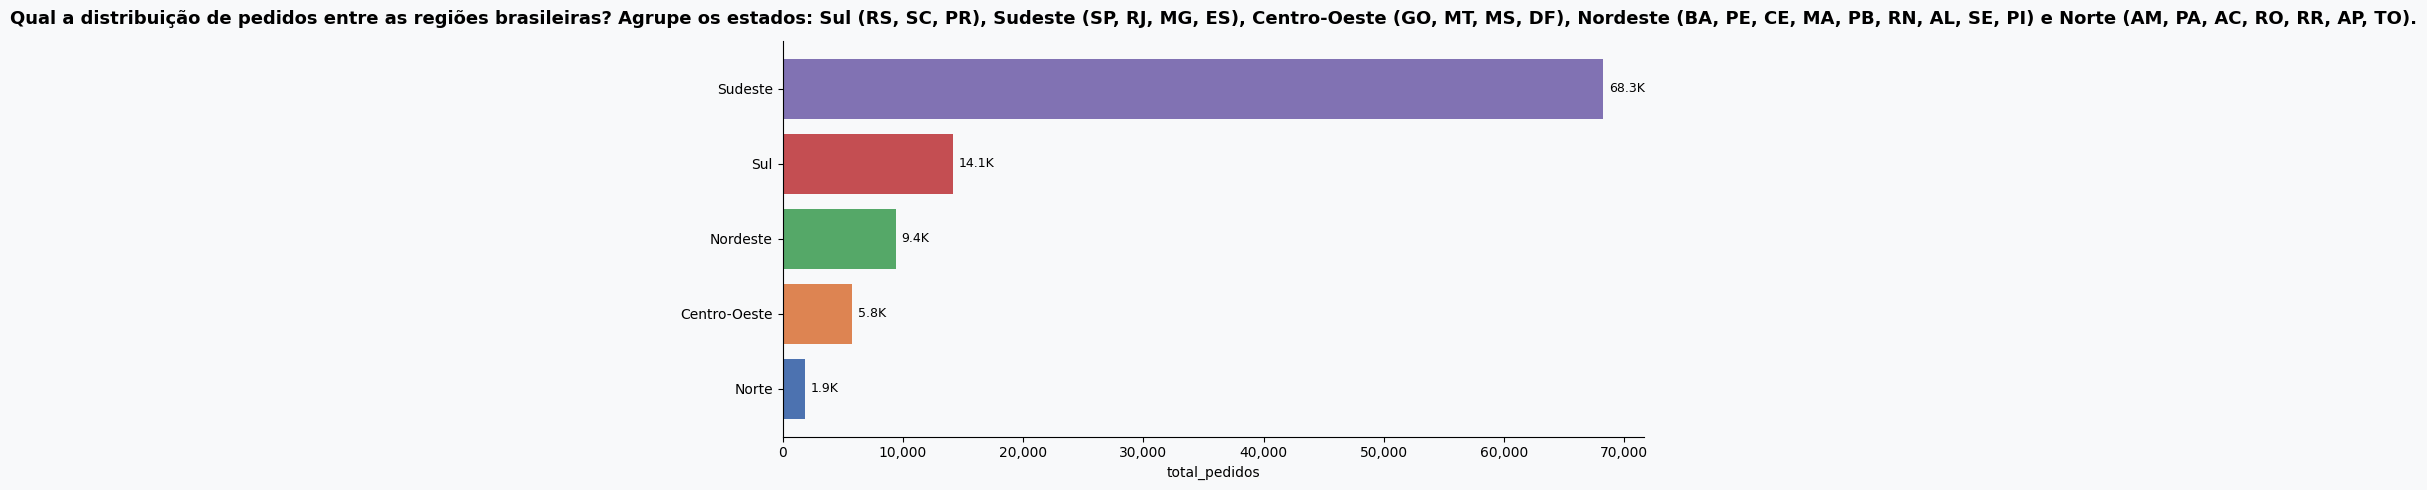

In [20]:
# 4 - Análise de consumidores:

# Consulta 1:
exibir_resposta('Quais estados têm maior volume de pedidos e qual o ticket médio por estado?')

# Consulta 2:
exibir_resposta('Quais estados têm maior atraso médio nas entregas para os consumidores?')

# Consulta 3:
exibir_resposta(
    'Qual a distribuição de pedidos entre as regiões brasileiras? '
    'Agrupe os estados: Sul (RS, SC, PR), Sudeste (SP, RJ, MG, ES), '
    'Centro-Oeste (GO, MT, MS, DF), Nordeste (BA, PE, CE, MA, PB, RN, AL, SE, PI) '
    'e Norte (AM, PA, AC, RO, RR, AP, TO).'
)


In [21]:
# Validação manual - Análise de consumidores:

conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

print('Volume de pedidos e ticket médio por estado - Top 10:')
r = cursor.execute("""
    SELECT dc.estado, COUNT(*) AS total_pedidos,
           ROUND(AVG(fpt.valor_total_pago_brl), 2) AS ticket_medio
    FROM fat_pedido_total fpt
    JOIN dim_consumidores dc ON fpt.id_consumidor = dc.id_consumidor
    GROUP BY dc.estado
    ORDER BY total_pedidos DESC LIMIT 10
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[1]:,} pedidos | Ticket médio: R$ {row[2]:.2f}')

conn.close()

Volume de pedidos e ticket médio por estado - Top 10:
  SP: 41,746 pedidos | Ticket médio: R$ 143.69
  RJ: 12,852 pedidos | Ticket médio: R$ 166.85
  MG: 11,635 pedidos | Ticket médio: R$ 160.92
  RS: 5,466 pedidos | Ticket médio: R$ 162.99
  PR: 5,045 pedidos | Ticket médio: R$ 160.78
  SC: 3,637 pedidos | Ticket médio: R$ 171.32
  BA: 3,380 pedidos | Ticket médio: R$ 182.44
  DF: 2,140 pedidos | Ticket médio: R$ 165.95
  ES: 2,033 pedidos | Ticket médio: R$ 160.34
  GO: 2,020 pedidos | Ticket médio: R$ 173.31


 Pergunta: Quais os 3 produtos mais vendidos em cada um dos 5 estados com maior volume de pedidos (SP, RJ, MG, RS, PR)?

 Resposta:
Aqui estão os 3 produtos mais vendidos em cada um dos 5 estados com maior volume de pedidos (SP, RJ, MG, RS, PR):

**Minas Gerais (MG):**
1. Cabo HDMI Rosa (82 vendas)
2. Kit de Ferramentas Ultra (68 vendas)
3. Cobertor Cinza (64 vendas)

**Paraná (PR):**
1. Relógio Analógico Verde (28 vendas)
2. Cortador de Grama Branco (27 vendas)
3. Kit de Ferramentas (25 vendas)

**Rio de Janeiro (RJ):**
1. Cabo HDMI Rosa (102 vendas)
2. Colar (75 vendas)
3. Cortador de Grama Branco (72 vendas)

**Rio Grande do Sul (RS):**
1. Cortador de Grama Branco (42 vendas)
2. Estante de Livros Luxo (39 vendas)
3. Cobertor Cinza (33 vendas)

**São Paulo (SP):**
1. Estante de Livros Luxo (265 vendas)
2. Cobertor Cinza (231 vendas)
3. Cortador de Grama Branco (181 vendas)

 SQL gerado:
WITH VendasPorProdutoPorEstado AS (
    SELECT
        dc.estado,
        dp.id_produto,
        d

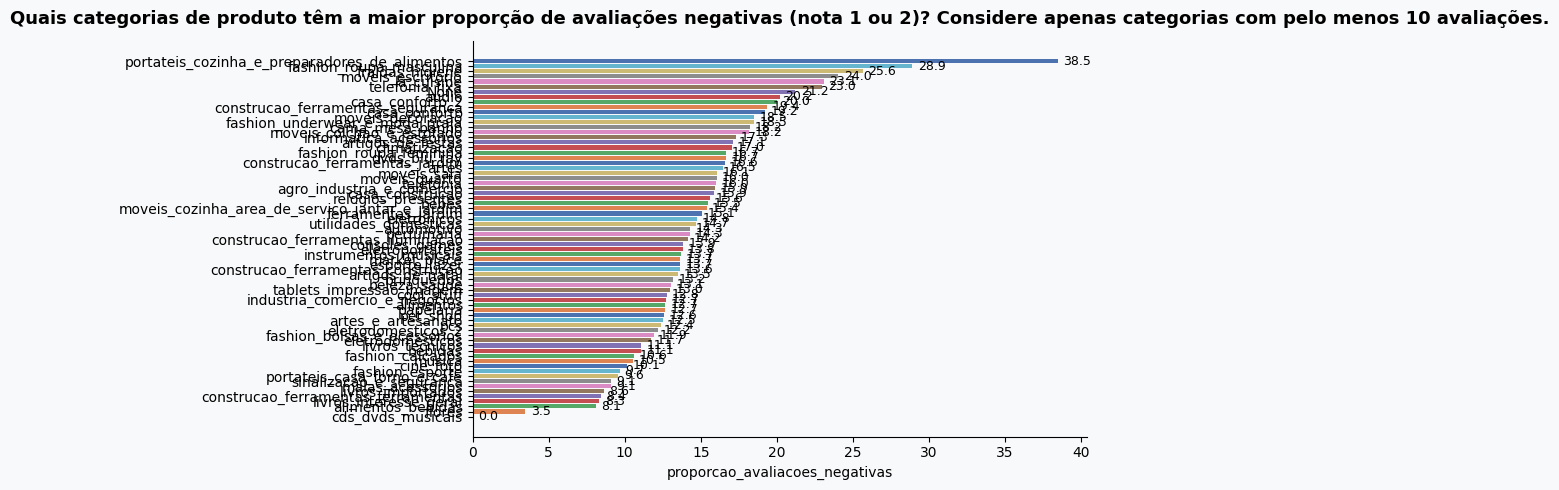

 Pergunta: Quais os 10 vendedores com maior receita total gerada?
Erro 503 da API. Tentativa 1/3 — aguardando 15s...

 Resposta:
Os 10 vendedores com maior receita total são:

1. Ester Sá: R$ 507.166,91
2. Srta. Stephany Gomes: R$ 308.222,04
3. Mathias Gonçalves: R$ 301.245,27
4. Henry Gabriel Nascimento: R$ 290.253,42
5. Ana Costa: R$ 284.903,08
6. Heloisa Santos: R$ 272.219,32
7. Murilo Costa: R$ 264.166,12
8. Sra. Maria Flor Aparecida: R$ 236.322,30
9. Isabela Santos: R$ 206.513,23
10. Matheus Vasconcelos: R$ 185.134,21

Estes são os vendedores que mais contribuíram para a receita total do e-commerce, com Ester Sá liderando significativamente.

 SQL gerado:
SELECT dv.nome_vendedor, ROUND(SUM(fpt.valor_total_pago_brl), 2) AS receita_total_brl FROM fat_itens_pedidos fi JOIN fat_pedido_total fpt ON fi.id_pedido = fpt.id_pedido JOIN dim_vendedores dv ON fi.id_vendedor = dv.id_vendedor GROUP BY dv.id_vendedor, dv.nome_vendedor ORDER BY receita_total_brl DESC LIMIT 10;

 Tem dados: True



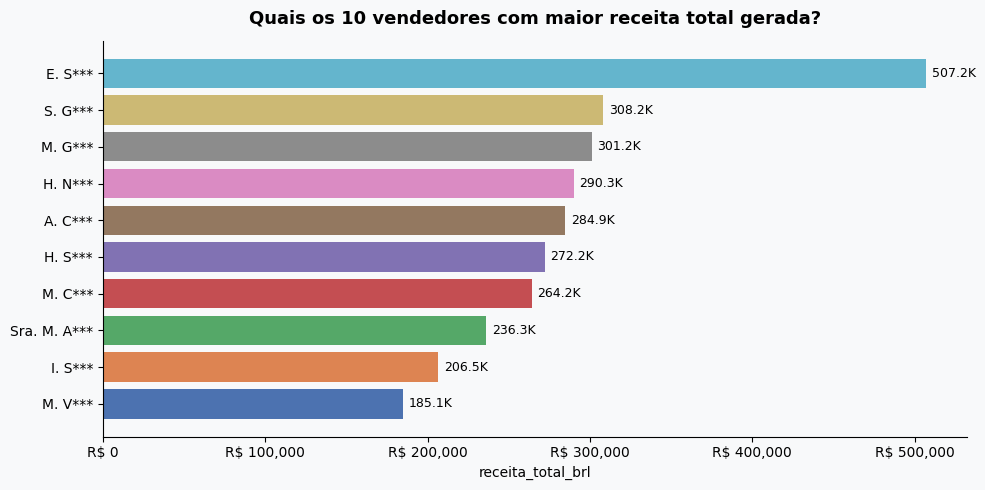

In [23]:
# 5 - Análise de Vendedores e Produtos:

# Consulta 1:
exibir_resposta(
    'Quais os 3 produtos mais vendidos em cada um dos 5 estados com maior volume de pedidos '
    '(SP, RJ, MG, RS, PR)?'
)

# Consulta 2:
exibir_resposta(
    'Quais categorias de produto têm a maior proporção de avaliações negativas '
    '(nota 1 ou 2)? Considere apenas categorias com pelo menos 10 avaliações.'
)

# Consulta 3:
exibir_resposta('Quais os 10 vendedores com maior receita total gerada?')

In [22]:
# Validação manual - Análise de Vendedores e Produtos:

# Validação manual — 4.5
conn = sqlite3.connect(BANCO_DESTINO)
cursor = conn.cursor()

print('Produtos mais vendidos por estado - SP, RJ, MG, RS, PR:')
for estado in ['SP', 'RJ', 'MG', 'RS', 'PR']:
    r = cursor.execute("""
        SELECT dp.nome_produto, COUNT(*) AS total
        FROM fat_itens_pedidos fi
        JOIN dim_produtos dp ON fi.id_produto = dp.id_produto
        JOIN fat_pedidos fp ON fi.id_pedido = fp.id_pedido
        JOIN dim_consumidores dc ON fp.id_consumidor = dc.id_consumidor
        WHERE dc.estado = ?
        GROUP BY dp.id_produto ORDER BY total DESC LIMIT 3
    """, (estado,)).fetchall()
    produtos = ' | '.join([f"{row[0]} ({row[1]}x)" for row in r])
    print(f'  {estado}: {produtos}')

print('\n Categorias com mais taxa de avaliação negativa (mín. 10 avaliações):')
r = cursor.execute("""
    SELECT dp.categoria_produto, COUNT(*) AS total,
           SUM(CASE WHEN fa.avaliacao <= 2 THEN 1 ELSE 0 END) AS negativas,
           ROUND(100.0 * SUM(CASE WHEN fa.avaliacao <= 2 THEN 1 ELSE 0 END)
                 / COUNT(*), 1) AS pct_negativa
    FROM fat_itens_pedidos fi
    JOIN dim_produtos dp ON fi.id_produto = dp.id_produto
    JOIN fat_avaliacoes_pedidos fa ON fi.id_pedido = fa.id_pedido
    WHERE dp.categoria_produto IS NOT NULL
    GROUP BY dp.categoria_produto
    HAVING total >= 10
    ORDER BY pct_negativa DESC LIMIT 10
""").fetchall()
for row in r:
    print(f'  {row[0]}: {row[3]}% negativas ({row[2]} de {row[1]})')

conn.close()



Produtos mais vendidos por estado - SP, RJ, MG, RS, PR:
  SP: Estante de Livros Luxo (265x) | Cobertor Cinza (231x) | Cortador de Grama Branco (181x)
  RJ: Cabo HDMI Rosa (102x) | Colar (75x) | Cortador de Grama Branco (72x)
  MG: Cabo HDMI Rosa (82x) | Kit de Ferramentas Ultra (68x) | Cobertor Cinza (64x)
  RS: Cortador de Grama Branco (42x) | Estante de Livros Luxo (39x) | Cobertor Cinza (33x)
  PR: Relógio Analógico Verde (28x) | Cortador de Grama Branco (27x) | Kit de Ferramentas (25x)

 Categorias com mais taxa de avaliação negativa (mín. 10 avaliações):
  portateis_cozinha_e_preparadores_de_alimentos: 38.5% negativas (5 de 13)
  fashion_roupa_masculina: 28.9% negativas (37 de 128)
  fraldas_higiene: 25.6% negativas (10 de 39)
  moveis_escritorio: 24.0% negativas (382 de 1590)
  la_cuisine: 23.1% negativas (3 de 13)
  telefonia_fixa: 23.0% negativas (57 de 248)
  audio: 20.2% negativas (69 de 342)
  casa_conforto_2: 20.0% negativas (5 de 25)
  construcao_ferramentas_seguranca: 19.